In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PATH = PROJECT_ROOT / "outputs" / "motif_matrix_numeric_v0_1.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

print("Project root:", PROJECT_ROOT)
print("Data path exists:", DATA_PATH.exists())

Project root: c:\Users\zhowa\Documents\GitHub\FloodMyth
Data path exists: True


In [2]:
df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(12, 74)


,story_id,story_name,culture,region,primary_source,source_type,story_type,overall_confidence,source_caution,notes,...,immortality_or_godlike_reward,new_rules_or_order_after_flood,population_control_after_flood,humanity_restored_after_flood,ritual_recreation_after_flood,stones_bones_blood_or_material_recreation,civilization_restored_after_flood,hydraulic_engineering_or_public_works,animal_body_or_species_origin_motif,source_biblical_influence_caution
0,FM-001,Genesis Flood / Noah,Israelite-Judahite,Levant,"Genesis 6:9–9:17, NIV",Scriptural narrative,survivor-ark flood,high,Canonical text; strong internal chronology and...,Moral corruption/violence causes flood; Noah r...,...,0.0,1.0,0.0,1.0,0.0,0.0,0.5,0.0,0.0,0.0
1,FM-002,Gilgamesh Tablet XI / Utanapishtim,Mesopotamian / Babylonian-Akkadian,Mesopotamia,"Epic of Gilgamesh, Tablet XI",Epic / mythic narrative,secret-warning ark flood,high,Cause is less explicit in Tablet XI; strong pa...,Ea secretly warns Utanapishtim through a reed ...,...,1.0,0.0,0.0,0.5,0.0,0.0,0.5,0.0,0.0,0.0
2,FM-003,Atrahasis Flood,Mesopotamian / Akkadian-Babylonian,Mesopotamia,Atrahasis flood account,Epic / mythic narrative,noise-cause survivor flood,medium,Fragmentary sections; several aftermath detail...,Humans are created to serve gods; population/n...,...,0.0,1.0,1.0,0.5,0.0,0.0,0.0,0.0,0.0,0.0
3,FM-004,Eridu Genesis / Ziusudra,Sumerian / Mesopotamian,Mesopotamia,Eridu Genesis / Ziusudra flood account,Sumerian mythic narrative,king-priest secret-warning flood,medium,Significant lacunae; boat details and some aft...,Ziusudra is a pious king-priest/seer warned in...,...,1.0,NaN,0.0,0.5,0.0,0.0,0.5,0.0,0.0,0.0
4,FM-005,Deucalion and Pyrrha,Greek / Mediterranean,Greece,"Apollodorus, Library 1.7.2",Mythographic summary,survivor-chest flood,high,Moral cause less developed in Apollodorus than...,Prometheus advises Deucalion; Deucalion and Py...,...,0.0,0.5,0.0,1.0,0.0,1.0,0.5,0.0,0.0,0.0


In [3]:
metadata_cols = [
    "story_id",
    "story_name",
    "culture",
    "region",
    "primary_source",
    "source_type",
    "story_type",
    "overall_confidence",
    "source_caution",
    "notes",
    "include_in_core_analysis",
    "analysis_group",
    "recommended_first_visual",
    "score_notes",
]

score_cols = [
    "present_motif_score",
    "uncertain_or_partial_count",
    "core_survivor_package_score",
    "expanded_flood_catastrophe_score",
]

metadata_cols = [col for col in metadata_cols if col in df.columns]
score_cols = [col for col in score_cols if col in df.columns]

motif_cols = [
    col for col in df.columns
    if col not in metadata_cols and col not in score_cols
]

print("Motif columns:", len(motif_cols))
motif_cols

Motif columns: 56


['moral_cause',
 'noise_or_overpopulation_cause',
 'failed_creation_cause',
 'primordial_or_cosmic_disorder',
 'world_age_cycle',
 'divine_decision_to_flood_or_destroy',
 'council_or_multiple_deities',
 'flood_as_natural_or_sea_overflow',
 'blood_flood',
 'flood_control_governance_problem',
 'chosen_survivor_or_group',
 'survivor_righteous_pious_religious',
 'survivor_is_king_priest_ruler',
 'survivor_couple',
 'family_or_household_saved',
 'animal_or_supernatural_helper_warning',
 'divine_or_supernatural_warning',
 'warning_secret_indirect_wall',
 'dream_warning',
 'specific_warning_timing',
 'boat_or_vessel',
 'non_boat_container_or_tree_chest_vessel',
 'construction_instructions',
 'specific_vessel_dimensions',
 'pitch_or_waterproofing',
 'food_stored_or_rationed',
 'animals_preserved_or_co_survive',
 'civilization_knowledge_or_craftsmen_preserved',
 'mountain_landing_or_refuge',
 'waters_recede_or_subside',
 'storm_or_rain',
 'water_from_above_and_below_or_cosmic_sources',
 'sea_la

In [4]:
df["story_label"] = df["story_name"].str.replace(" / ", "\n", regex=False)

df[["story_id", "story_name", "story_type", "include_in_core_analysis"]]

,story_id,story_name,story_type,include_in_core_analysis
0,FM-001,Genesis Flood / Noah,survivor-ark flood,yes
1,FM-002,Gilgamesh Tablet XI / Utanapishtim,secret-warning ark flood,yes
2,FM-003,Atrahasis Flood,noise-cause survivor flood,yes
3,FM-004,Eridu Genesis / Ziusudra,king-priest secret-warning flood,yes
4,FM-005,Deucalion and Pyrrha,survivor-chest flood,yes
5,FM-006,Manu and the Fish,animal-helper ritual-recreation flood,yes
6,FM-007,Yu Controls the Flood,flood-control civilization-restoration myth,no
7,FM-008,Popol Vuh / Destruction of the Wooden People,failed-creation destruction flood,no
8,FM-009,Huarochirí / The Llama Warns of the Flood,animal-warning mountain-refuge flood,caution
9,FM-010,Nahui Atl / Tata and Nene,world-age flood with survivor transformation,no


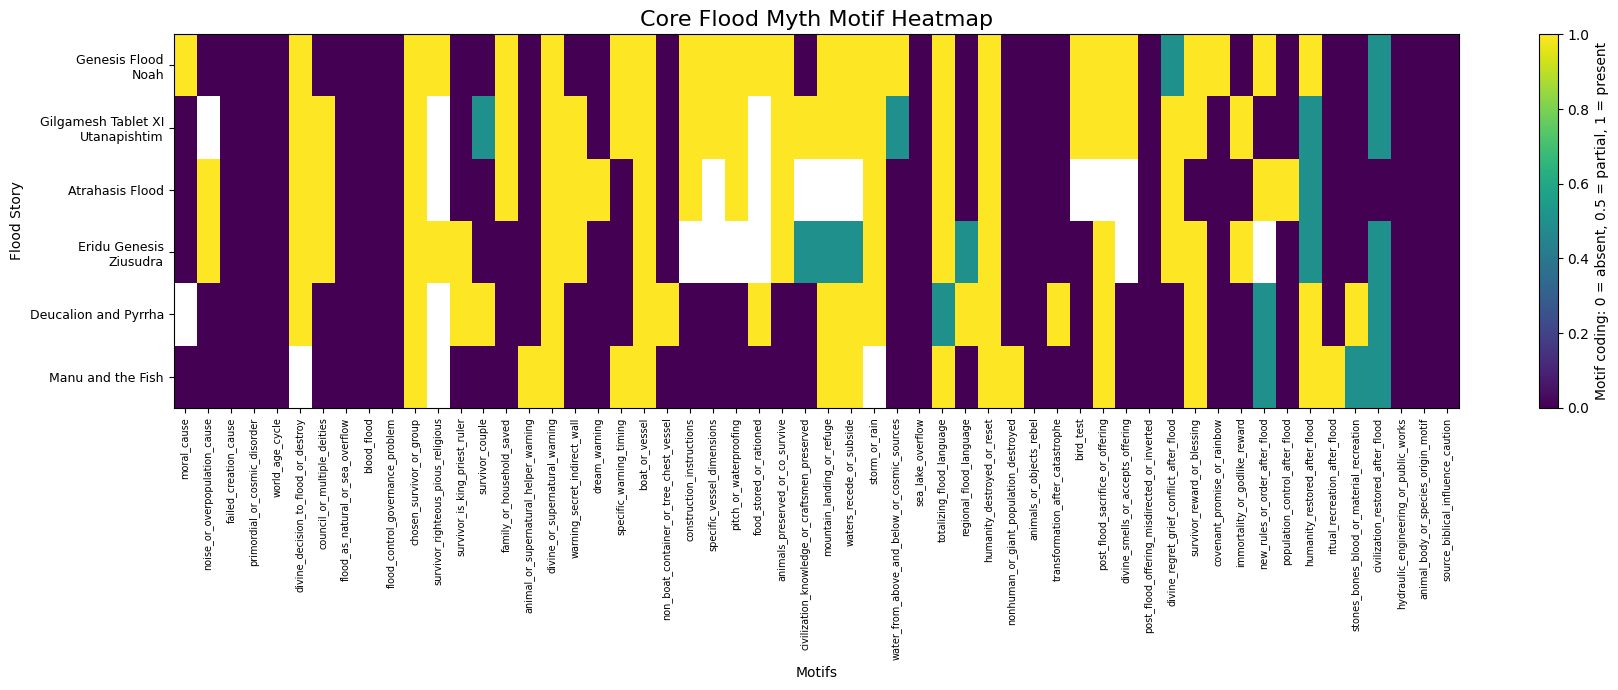

WindowsPath('c:/Users/zhowa/Documents/GitHub/FloodMyth/outputs/core_motif_heatmap_v0_1.png')

In [5]:
core_df = df[df["include_in_core_analysis"].str.lower() == "yes"].copy()

core_matrix = core_df[motif_cols].astype(float)
core_labels = core_df["story_label"]

plt.figure(figsize=(18, 7))

plt.imshow(core_matrix, aspect="auto", interpolation="nearest")

plt.yticks(
    ticks=np.arange(len(core_labels)),
    labels=core_labels,
    fontsize=9,
)

plt.xticks(
    ticks=np.arange(len(motif_cols)),
    labels=motif_cols,
    rotation=90,
    fontsize=7,
)

plt.title("Core Flood Myth Motif Heatmap", fontsize=16)
plt.xlabel("Motifs")
plt.ylabel("Flood Story")

plt.colorbar(label="Motif coding: 0 = absent, 0.5 = partial, 1 = present")

plt.tight_layout()

core_heatmap_path = OUTPUT_DIR / "core_motif_heatmap_v0_1.png"
plt.savefig(core_heatmap_path, dpi=300, bbox_inches="tight")

plt.show()

core_heatmap_path

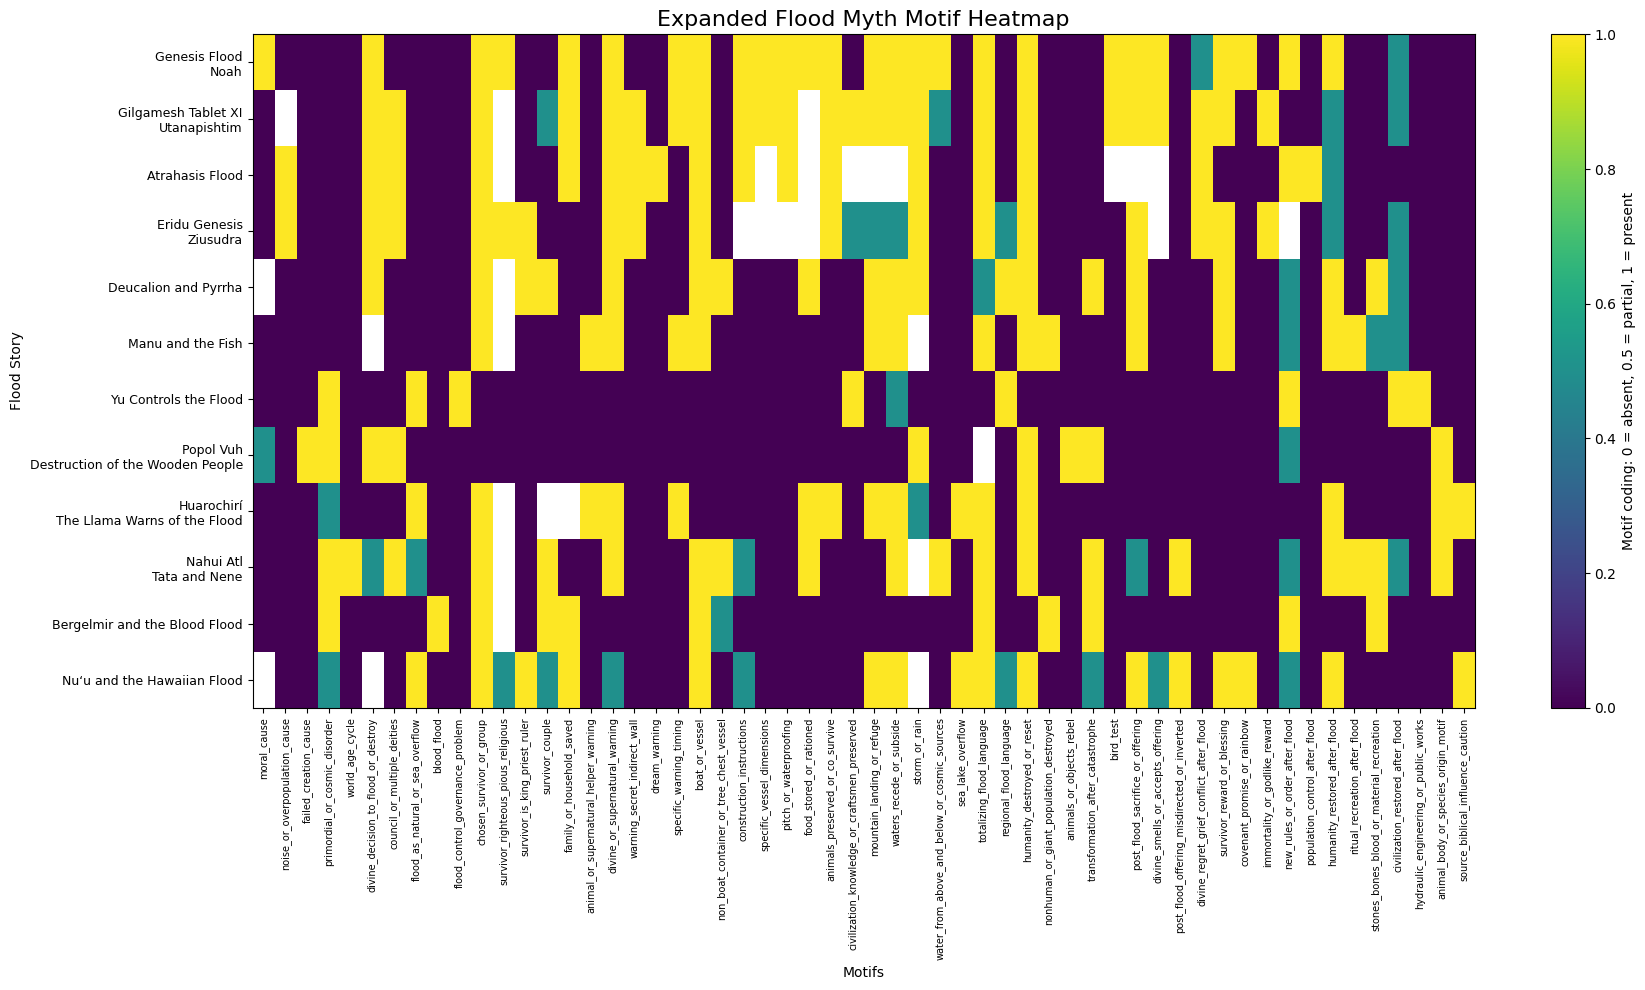

WindowsPath('c:/Users/zhowa/Documents/GitHub/FloodMyth/outputs/expanded_motif_heatmap_v0_1.png')

In [6]:
expanded_matrix = df[motif_cols].astype(float)
expanded_labels = df["story_label"]

plt.figure(figsize=(18, 10))

plt.imshow(expanded_matrix, aspect="auto", interpolation="nearest")

plt.yticks(
    ticks=np.arange(len(expanded_labels)),
    labels=expanded_labels,
    fontsize=9,
)

plt.xticks(
    ticks=np.arange(len(motif_cols)),
    labels=motif_cols,
    rotation=90,
    fontsize=7,
)

plt.title("Expanded Flood Myth Motif Heatmap", fontsize=16)
plt.xlabel("Motifs")
plt.ylabel("Flood Story")

plt.colorbar(label="Motif coding: 0 = absent, 0.5 = partial, 1 = present")

plt.tight_layout()

expanded_heatmap_path = OUTPUT_DIR / "expanded_motif_heatmap_v0_1.png"
plt.savefig(expanded_heatmap_path, dpi=300, bbox_inches="tight")

plt.show()

expanded_heatmap_path

In [7]:
motif_frequency = (
    df[motif_cols]
    .astype(float)
    .sum(axis=0)
    .sort_values(ascending=False)
    .reset_index()
)

motif_frequency.columns = ["motif", "weighted_presence_score"]

motif_frequency.head(20)

,motif,weighted_presence_score
0,chosen_survivor_or_group,10.0
1,humanity_destroyed_or_reset,10.0
2,totalizing_flood_language,9.5
3,boat_or_vessel,9.0
4,divine_or_supernatural_warning,8.5
5,waters_recede_or_subside,8.0
6,humanity_restored_after_flood,7.5
7,divine_decision_to_flood_or_destroy,6.5
8,mountain_landing_or_refuge,6.5
9,post_flood_sacrifice_or_offering,6.5


In [8]:
motif_frequency_path = OUTPUT_DIR / "motif_frequency_v0_1.csv"

motif_frequency.to_csv(motif_frequency_path, index=False)

motif_frequency_path

WindowsPath('c:/Users/zhowa/Documents/GitHub/FloodMyth/outputs/motif_frequency_v0_1.csv')